# Q2: Unsupervised Learning — Customer Segmentation
## Task 1: Data Preparation

In [1]:
import pandas as pd

df = pd.read_csv('q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Feature scaling is essential before applying K-Means clustering because the algorithm groups data points based on distance (typically Euclidean distance).

In this dataset, features such as annual_spend and basket_size have much larger values compared to features like visits_per_month or num_categories_purchased. Without scaling, these larger-value features would dominate the distance calculations and bias the clustering results.

To address this, StandardScaler is used to standardize all features so that they have a mean of 0 and a standard deviation of 1. This ensures that each feature contributes equally to the clustering process and leads to more meaningful and balanced clusters.

## Task 2: Choosing K using Elbow Method

In [3]:
from sklearn.cluster import KMeans

wcss = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

wcss

[3000.000000000002,
 968.9938714074852,
 561.2530064181284,
 444.93027573720167,
 402.3713031925936,
 370.38539307163506,
 346.9540807873125,
 319.89747536997453,
 303.2822502154262,
 289.113978541058]

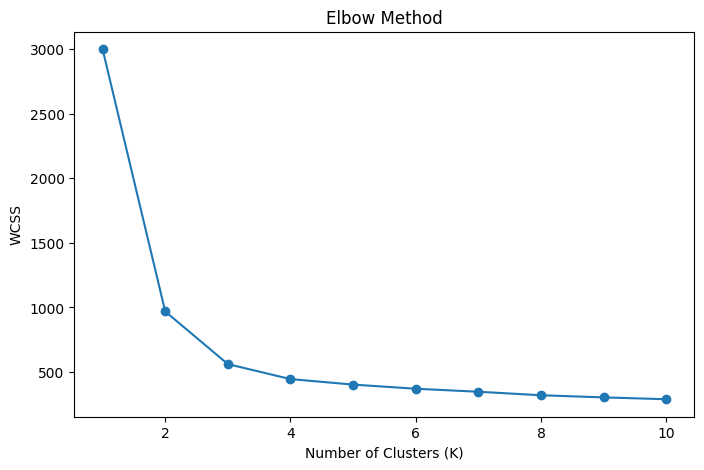

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

The Elbow Method was used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS) for different values of K.

From the plot, there is a sharp decrease in WCSS from K = 1 to K = 3, indicating that adding clusters significantly improves the model up to this point. After K = 3, the rate of decrease slows down and the curve begins to flatten, showing diminishing returns.

This point of inflection (the "elbow") suggests that K = 3 is the optimal number of clusters for this dataset, as it provides a good balance between model complexity and performance.

## Task 3: K-Means Clustering

In [5]:
from sklearn.cluster import KMeans

# Apply KMeans with K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(df_scaled)

# Add cluster column to original dataframe
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [6]:
# Centroids (in scaled form)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_scaled.columns)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


The K-Means algorithm was applied with K = 3 to segment customers into distinct groups based on their behavior.

Cluster 0:
This cluster represents low-value customers. These customers have lower annual spending, smaller basket sizes, and purchase fewer product categories. Although they visit relatively frequently, their overall contribution to revenue is low. These customers can be targeted with upselling strategies.

Cluster 1:
This cluster represents high-value customers. They have high annual spending, large basket sizes, and purchase from a wide range of categories. However, they visit less frequently and have higher days since last visit. These customers are important for business revenue and should be targeted with retention strategies and personalized offers.

Cluster 2:
This cluster represents average or moderate customers. Their spending, visit frequency, and purchasing behavior are close to the overall average. These customers have balanced engagement and can be nurtured to move into the high-value segment.

## Task 4: Dimensionality Reduction using PCA

In [7]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)

pca_components = pca.fit_transform(df_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])

pca_df.head()

,PC1,PC2
0,-0.333082,0.109379
1,-2.255362,0.048458
2,-0.092905,-0.679257
3,-2.017598,-0.308845
4,-2.917762,0.529368


In [8]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [9]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df_scaled.columns,
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


Principal Component Analysis (PCA) was applied to reduce the dataset into two principal components while preserving most of the variance.

Explained Variance Ratio:
The first principal component (PC1) explains approximately 83.56% of the total variance, while the second principal component (PC2) explains around 5.56%. This indicates that PC1 captures the majority of the information in the dataset.

Interpretation of Components:

PC1:
PC1 has strong positive contributions from features such as age, annual_spend, basket_size, days_since_last_visit, and num_categories_purchased, while visits_per_month has a negative contribution.
This suggests that PC1 represents overall customer value and spending behavior. Customers with high PC1 scores tend to spend more, purchase more categories, and have larger basket sizes, but may visit less frequently.

PC2:
PC2 is mainly influenced by visits_per_month (positive contribution) and age and basket_size (negative contribution).
This indicates that PC2 captures customer engagement and visit frequency patterns. Customers with higher PC2 scores tend to visit more frequently, regardless of their spending levels.

Overall:
PCA effectively reduces the dimensionality of the dataset while retaining most of the important information, making it easier to visualize and analyze customer segments.

## Task 5: Cluster Visualisation using PCA

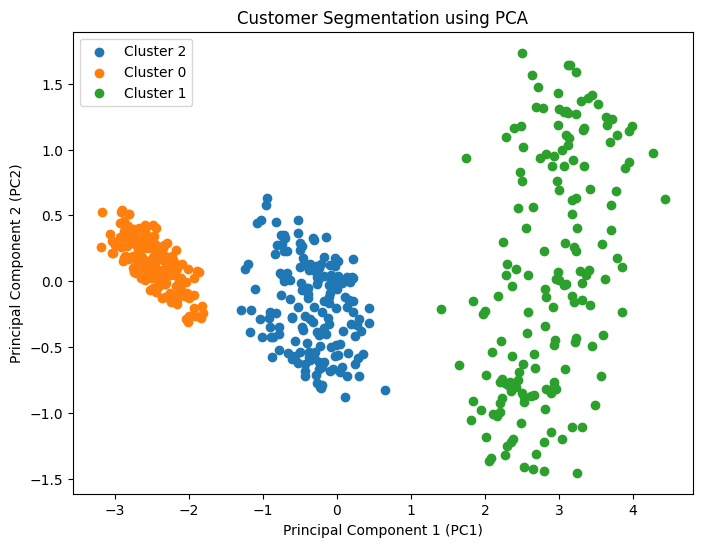

In [10]:
import matplotlib.pyplot as plt

# Add cluster labels to PCA dataframe
pca_df['cluster'] = df['cluster']

# Plot
plt.figure(figsize=(8,6))

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.title('Customer Segmentation using PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()

plt.show()

The scatter plot shows customer segments visualized using the first two principal components (PC1 and PC2).

Each point represents a customer, and different colors indicate different clusters identified by the K-Means algorithm.

Observations:
The clusters are clearly well separated along the PC1 axis, indicating that the first principal component plays a major role in distinguishing customer groups.

Cluster 0 (left side) consists of customers with lower PC1 values, representing low-value or low-spending customers.

Cluster 2 (center) represents moderate customers with average behavior across features.

Cluster 1 (right side) consists of customers with high PC1 values, representing high-value customers with higher spending and purchasing activity.

The separation between clusters is distinct with minimal overlap, indicating that the clustering is effective.

Conclusion:
PCA successfully reduces the data into two dimensions while preserving key patterns, and the visualization confirms that K-Means has formed meaningful and well-defined customer segments.